# Toy problem: RV-SDDP versus Cyclic SDDP

This notebook reproduces the numerical experiments on the toy problem presented in the accompanying paper. The problem is a simple infinite-horizon discounted reservoir management problem used to illustrate the convergence behavior of the proposed **RV-SDDP** algorithm and to compare it with **Cyclic SDDP**, i.e., the variant without shifts.

In [1]:
using Revise
using RVSDDP
using Random
using Plots
using Gurobi
using Statistics
# using HiGHS
# optimizer = () -> HiGHS.Optimizer()
using Gurobi
const GRB_ENV = Gurobi.Env()
optimizer=() -> Gurobi.Optimizer(GRB_ENV)
using LaTeXStrings

Set parameter Username
Set parameter LicenseID to value 2818369
Academic license - for non-commercial use only - expires 2027-05-05


## Run RV-SDDP and Cyclic SDDP

In [34]:
discount_factor=0.99
period = 3
graph=RVSDDP.InfiniteLinearGraph(period);

In [35]:
function subproblem_builder(subproblem::Model, node::Int, discount_factor::Float64)
    # State variables
    N=1
    @variable(subproblem, 0 <= volume[1:N] <= 200, RVSDDP.State, initial_value = 50)
    # Control variables
    @variables(subproblem, begin
        thermal_generation[1:4] >= 0
        thermal_generation_tot >= 0
        hydro_generation[1:N] >= 0
        hydro_spill[1:N] >= 0
        deficit >= 0
    end)
    # Random variables
    @variable(subproblem, inflow)
    Ω = [20.0, 80.0]
    # Ω = [40.0]
    P = [1 / length(Ω) for _ in Ω]
    # Ω = [70.0]
    # P = [1.0]
    RVSDDP.parameterize(subproblem, Ω, P) do ω
        return JuMP.fix(inflow, ω)
    end

    capa_th = [10 15 10 5] 
    c_th = [1 2 5 10]
    # Transition function and constraints
    @constraints(
        subproblem,
        begin
            [i in 1:N], volume[i].out == volume[i].in - hydro_generation[i] - hydro_spill[i] + inflow
            [i in 1:N], hydro_generation[i] <= 100
            [i in 1:1], thermal_generation[i] <= capa_th[i]
            thermal_generation_tot==sum(thermal_generation[i] for i in 1:4)
            deficit + sum(hydro_generation[i] for i in 1:N) + thermal_generation_tot == 60
        end
    )
    # Stage-objective
    @stageobjective(subproblem, 1*(50*sum(hydro_spill[i] for i in 1:N) + 50 * deficit+ sum(thermal_generation[i]*c_th[i] for i in 1:4)))
    return subproblem
end

subproblem_builder (generic function with 1 method)

In [30]:
model_no_shift = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_no_shift; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 100, infinite = true, shift_function=RVSDDP.no_shift); 

In [52]:
model_rvsddp = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_rvsddp; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 31, infinite = true, shift_function=RVSDDP.shift_update_random_forward); 

## Comparison of value function approximations obtained by RV-SDDP and cyclic SDDP after 100 iterations.

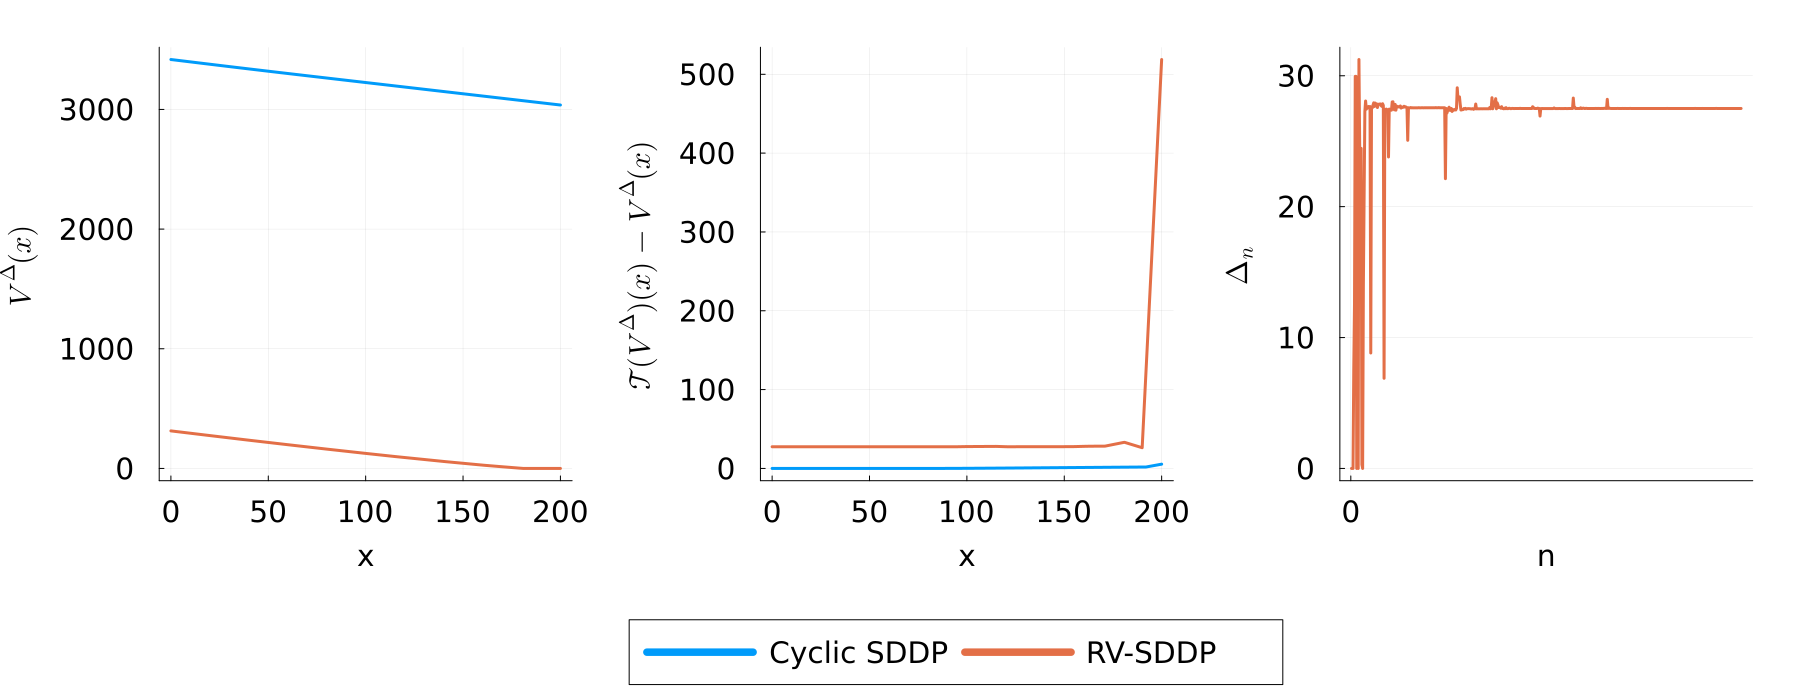

In [53]:
fontsize = 20
ind = 0:0.5:200
V_no_shift = [RVSDDP.compute_V(model_no_shift[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
V_RVSDDP = [RVSDDP.compute_V(model_rvsddp[1].value_function, Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]

TV_no_shift = [RVSDDP.compute_TV(model_no_shift[1], Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]
TV_RVSDDP = [RVSDDP.compute_TV(model_rvsddp[1], Dict(Symbol("volume[1]")=>1.0*i)) for i in ind]

p1 = plot(
    ind,
    V_no_shift,
    label = false,
    xlabel = "x",
    ylabel = L"V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p1, ind, V_RVSDDP, label = false, linewidth = 3)

p2 = plot(
    ind,
    TV_no_shift - V_no_shift,
    label = false,
    xlabel = "x",
    ylabel = L"\mathcal{T}(V^\Delta)(x) - V^\Delta(x)",
    guidefontsize = fontsize,
    tickfontsize = fontsize,
    linewidth = 3,
    margin = 10Plots.mm,
)
plot!(p2, ind, TV_RVSDDP - V_RVSDDP, label = false, linewidth = 3)

p3=plot(label = false, xlabel="n", ylabel =L"\Delta_n",guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, margin=10Plots.mm)

plot!(p3, [cut.shift[1][1] for cut in model_rvsddp[1].value_function.cut_V], xticks = [0, 1500,3000,4500],label=false, linewidth=3, color = 2)

pleg = plot(
    [NaN], [NaN],
    label = "Cyclic SDDP",
    linewidth = 3,
    color = 1,
    framestyle = :none,
    legend = :bottom,
    legend_columns = 2,
    legendfontsize = fontsize,
    ticks = false,
    grid = false,
)
plot!(
    pleg,
    [NaN], [NaN],
    label = "RV-SDDP",
    linewidth = 3,
    color = 2,
)

plot(
    p1,
    p2,
    p3,
    pleg,
    layout = @layout([a b c; d{0.2h}]),
    size = (1800, 700),
)

## Value function approximations produced by cyclic SDDP at different iterations.

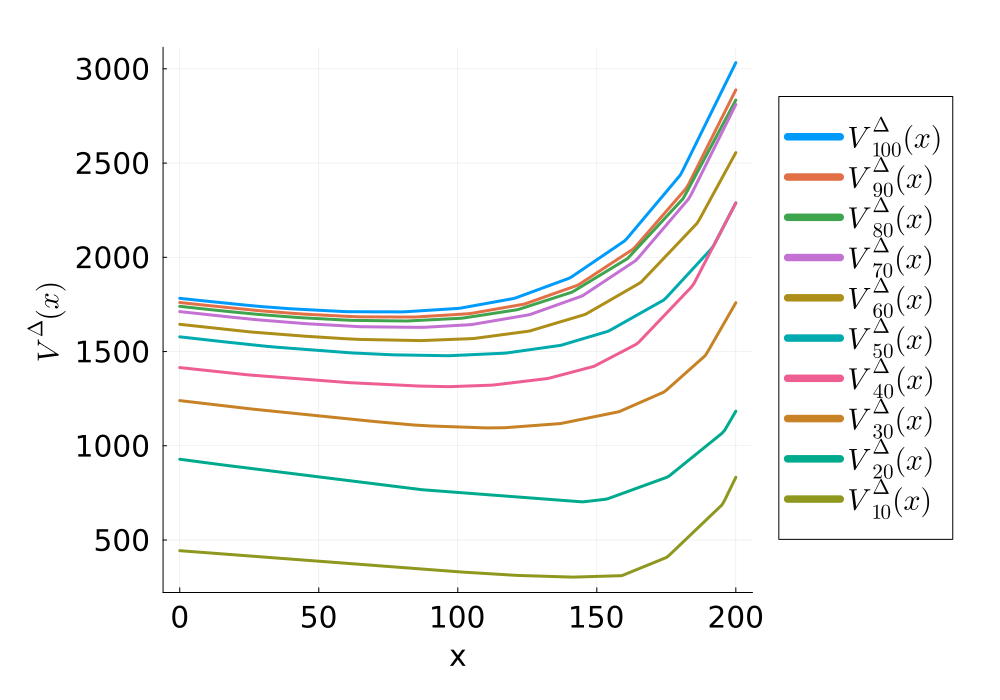

In [93]:
iter_max = 100
model_no_shift_list = [RVSDDP.PolicyGraph(
        subproblem_builder,
        graph;
        sense = :Min,
        lower_bound = 0.0,
        optimizer = optimizer,
        discount_factor=discount_factor,
    ) for iter in 10:10:iter_max]

for (i, iter) in enumerate(10:10:iter_max)
    RVSDDP.add_cuts(model_no_shift_list[i], model_no_shift, iter);
end

ind = 0:1:200

fontsize = 20

p=plot(xlabel="x", ylabel = L"V^\Delta(x)", guidefontsize=fontsize, tickfontsize=fontsize, legendfontsize=fontsize, size=(1000, 700), margin=10Plots.mm, legend=:outerright)
for k in 1:10
    i = 10-k+1
    iter = i*10
    V_no_shift = [RVSDDP.compute_V(model_no_shift_list[i][1].value_function, Dict(Symbol("volume[1]")=>1.0*j)) for j in ind]
    plot!(p, ind, V_no_shift, label = latexstring("V^\\Delta_{$iter}(x)"), linewidth = 3)
end
p

## Policy quality and number of active cuts after 31 iterations

The policy quality is evaluated by Monte Carlo simulation over \(N\) scenarios. For \(N=1000\), one evaluation takes approximately 2 minutes. The estimated policy costs are 1997.56 for Cyclic SDDP and 1728 for RV-SDDP.

In [36]:
N = 100
TimeHorizon = Int(ceil(log(0.001)/(log(discount_factor))))

688

In [37]:
model_no_shift = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_no_shift; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 31, infinite = true, shift_function=RVSDDP.no_shift); 

In [38]:
Random.seed!(12345)

simulations_no_shift= RVSDDP.simulate(
        model_no_shift,
        N;
        sampling_scheme = RVSDDP.InSampleMonteCarlo(max_depth=TimeHorizon),
)
println("Average cost for cyclic SDDP: ", mean([sum((discount_factor^(t-1))*simulations_no_shift[k][t][:stage_objective] for t in 1:TimeHorizon) for k in 1:N]))

Average cost for cyclic SDDP: 1973.7661020704663


In [39]:
[val for (_,val) in simulations_no_shift[1][end][:outgoing_state]]
simulations_no_shift[1]

688-element Vector{Dict{Symbol, Any}}:
 Dict(:bellman_term => 1347.1676291386332, :noise_term => 80.0, :outgoing_state => Dict(Symbol("volume[1]") => 80.0), :node_index => 1, :stage_objective => 10.0, :objective_state => nothing, :belief => Dict(1 => 1.0))
 Dict(:bellman_term => 1378.6946837933754, :noise_term => 20.0, :outgoing_state => Dict(Symbol("volume[1]") => 50.0), :node_index => 2, :stage_objective => 10.0, :objective_state => nothing, :belief => Dict(2 => 1.0))
 Dict(:bellman_term => 1344.3840385636497, :noise_term => 80.0, :outgoing_state => Dict(Symbol("volume[1]") => 80.0), :node_index => 3, :stage_objective => 10.0, :objective_state => nothing, :belief => Dict(3 => 1.0))
 Dict(:bellman_term => 1379.654891652091, :noise_term => 20.0, :outgoing_state => Dict(Symbol("volume[1]") => 50.0), :node_index => 1, :stage_objective => 10.0, :objective_state => nothing, :belief => Dict(1 => 1.0))
 Dict(:bellman_term => 1420.521391001143, :noise_term => 20.0, :outgoing_state => Dict(Sym

In [95]:
model_rvsddp = RVSDDP.PolicyGraph(
    subproblem_builder,
    graph;
    sense = :Min,
    lower_bound = 0.0,
    optimizer = optimizer,
    discount_factor=discount_factor,
)

Random.seed!(1)
parallel= 1
Cuts0=RVSDDP.train(model_rvsddp; refine_mode = 0, parallel=parallel, sampling_scheme=RVSDDP.InSampleMonteCarlo(max_depth=10000, rollout_limit = i -> period*i, parallel=parallel), iteration_limit = 31, infinite = true, shift_function=RVSDDP.shift_update_random_forward); 

In [105]:
Random.seed!(12345)

simulations_rvsddp= RVSDDP.simulate(
        model_rvsddp,
        N;
        sampling_scheme = RVSDDP.InSampleMonteCarlo(max_depth=TimeHorizon),
)
println("Average cost for RVSDDP: ", mean([sum((discount_factor^(t-1))*simulations_rvsddp[k][t][:stage_objective] for t in 1:TimeHorizon) for k in 1:N]))

Average cost for RVSDDP: 1728.4274146690432
